<a href="https://colab.research.google.com/github/Octa-Ibarra/Rl_Assigment7/blob/main/DQN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Aproximación de Funciones

En este taller vamos a cubrir ventajas que tiene utilizar aproximación de funciones en problemas de aprendizaje por refuerzo profundo. Ilustraremos el proceso con el problema de [Cart Pole](https://gymnasium.farama.org/environments/classic_control/cart_pole/), incluido en las librerías de Gym. El objetivo principal de este taller es comparar el desempeño de distintos algoritmos en su versión tabular y su versión con redes neuronales.

Para los talleres, de acá en adelante implementaremos redes nuronales con el framework [Stable Baselines3](https://stable-baselines3.readthedocs.io/en/master/index.html), que ya incluye varios algoritmos de aprendizaje por refuerzo.



# Instalación de Librerías  

Corra el siguiente bloque de código para instalar las librerías requeridas. Se encuentra incluído el módulo oficial de **Stable Baselines3** que ejecuta DQN, y el ambiente de Cart-Pole de Gym. Esta celda puede tardar un par de minutos en ejecutarse completamente la primera vez.


In [1]:
# Instalación de librerías en Colab.
%pip install -q stable_baselines3
%pip install -q "gymnasium[classic-control]"
%pip install -q imageio imageio-ffmpeg

import os
import sys
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio
from IPython.display import Video, display, clear_output

import stable_baselines3
from stable_baselines3 import DQN
from stable_baselines3.common.logger import configure
from stable_baselines3.common.logger import Logger, CSVOutputFormat, HumanOutputFormat
from stable_baselines3.common.evaluation import evaluate_policy
import gymnasium as gym


# Monta Google Drive y define la carpeta donde se guardan los videos.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    VIDEO_DIR = '/content/drive/MyDrive/Reinforcement/Assigment 7'
except Exception:
    VIDEO_DIR = './videos'
os.makedirs(VIDEO_DIR, exist_ok=True)


# Helper para grabar y reproducir videos del entorno en Colab.
# Si se llama play(filename="algo"), el video se guarda en VIDEO_DIR/algo.mp4.
class RenderFrame:
    _counter = 0

    def __init__(self, env, output_dir=None, fps=30):
        self.env = env
        self.frames = []
        self.fps = fps
        self.output_dir = output_dir or VIDEO_DIR
        os.makedirs(self.output_dir, exist_ok=True)

    def _capture(self):
        frame = self.env.render()
        if frame is not None:
            self.frames.append(frame)

    def reset(self, **kwargs):
        self.frames = []
        out = self.env.reset(**kwargs)
        self._capture()
        return out

    def step(self, action):
        out = self.env.step(action)
        self._capture()
        return out

    def play(self, filename=None, fps=None):
        if not self.frames:
            print("No hay frames capturados.")
            return
        save_dir = VIDEO_DIR
        os.makedirs(save_dir, exist_ok=True)
        if filename is None:
            RenderFrame._counter += 1
            filename = f"video_{RenderFrame._counter:02d}"
        if not filename.endswith(".mp4"):
            filename += ".mp4"
        full_path = os.path.join(save_dir, filename)
        imageio.mimsave(full_path, self.frames, fps=fps or self.fps)
        print(f"Video guardado en: {full_path}")
        display(Video(full_path, embed=True))

    def close(self):
        return self.env.close()

    def __getattr__(self, name):
        return getattr(self.env, name)


class _RenderlabAlias:
    RenderFrame = staticmethod(RenderFrame)

renderlab = _RenderlabAlias()

print("Todas las librerías instaladas correctamente.")
print(f"Carpeta de videos: {VIDEO_DIR}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 8.4 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Todas las librerías instaladas correctamente.
Carpeta de videos: ./videos


# Familiarización con el Entorno de Gym

El ambiente de Gym de [Cart Pole](https://gymnasium.farama.org/environments/classic_control/cart_pole/) consiste de un carro que debe moverse a la izquierda o a la derecha para intentar balancear un poste con un punto fijo que tiene pegado en la parte superior.

![Observation_space_cartpole](https://raw.githubusercontent.com/SSolanoRuniandes/Notebooks-Aprendizaje-por-Refuerzo-Profundo/main/Images/Observation_space_cartpole.png)

<center>Figura 4. Espacio de observación del ambiente de *CartPole*. [3]</center>

El ambiente está definido por un estado continuo en 4 dimensiones, que definen posición y velocidad del carro, y posición y velocidad angular del poste. Por otro lado, sólo hay dos acciones posibles: 0 el carro se mueve a la izquierda, y 1 el carro se mueve a la derecha. La meta es evitar que el poste caiga por el mayor tiempo posible, por lo que en cada paso de la simulación que el poste no caiga se obtiene recompensa +1. Si el poste sale del rango [-12°, 12°], el episodio se da por terminado, mientras que si el episodio supera los 500 pasos, se da por terminado con exito; en ambos casos se finaliza la simulación.

Esto quiere decir que el retorno sin descuento máximo que se podría obtener en una simulación es de 500.

## Ejemplo

En el siguiente bloque de código se muestra un ejemplo de cómo se simula un episodio del *CartPole*. En este caso siempre se toma la acción de ir a la izquierda (0).

In [2]:
#Ejemplo de simulación de un episodio de CartPole
env_prueba_1 = gym.make("CartPole-v1", render_mode="rgb_array") #Esta línea de código crea el ambiente.
env_prueba_1 = renderlab.RenderFrame(env_prueba_1, "./output") #Esta línea se utiliza para crear una copia que se pueda renderizar con renderlab

obs , info = env_prueba_1.reset() #Se reinicia el estado para comenzar. En obs se almacena el estado observado (continuo, 4 dimensiones)
terminated = False #Inicializa una condición para el loop
truncated = False #Inicializa una condición para el loop
total_reward=0 #Inicializa contador del retorno

while not (terminated or truncated): #Simula hasta que el poste caiga o hasta alcanzar 500 episodios (configuración de CartPole-v1)
  action=0 #Decide una acción. En este caso, siempre va a la izquierda
  obs, reward, terminated, truncated , info = env_prueba_1.step(action) #Con la función step el ambiente da un paso. Se obtiene el estado, recompensa y banderas de información
  total_reward+=reward #Llevamos una cuenta de la recompensa total

print("Recompensa obtenida en el episodio:",total_reward) #Después de terminar el episodio, imprimios la recompensa acumulada total obtenida
print("\n\n")

env_prueba_1.play(filename="00_familiarizacion_siempre_izquierda")

/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

Recompensa obtenida en el episodio: 9.0





Video guardado en: ./videos/00_familiarizacion_siempre_izquierda.mp4


Puede observar que el retorno obtenido fue de aproximadamente 10. Este valor es muy lejano del ideal 500 discutido anteriormente. Vemos igualmente que el video es muy corto porque falla casi de inmediato la tarea.

## Ejercicio práctico 1

Para comprobar el entendimiento de la simulación, modifique el ejemplo anterior cambiando la acción. Simule 10 episodios donde la acción sea sólo ir a la derecha y luego 10 episodios donde la acción se escoja aleatoriamente entre izquierda y derecha (recuerde utilizar la función reset() antes de comenzar un nuevo episodio). Calcule después la recompensa total promedio en cada caso y renderiza un video de la última simulación.

In [3]:
# Simulación de 10 episodios moviéndose siempre a la derecha
env_right = gym.make("CartPole-v1", render_mode="rgb_array")
env_right = renderlab.RenderFrame(env_right, "./output")

n_episodes = 10
rewards_right = []  # guarda recompensa total por episodio

for ep in range(n_episodes):
    obs, info = env_right.reset()  # reinicia antes de cada episodio
    terminated = False
    truncated = False
    total_reward = 0
    while not (terminated or truncated):
        action = 1  # siempre derecha
        obs, reward, terminated, truncated, info = env_right.step(action)
        total_reward += reward
    rewards_right.append(total_reward)
    print(f"Episodio {ep+1}: recompensa = {total_reward}")

mean_right = np.mean(rewards_right)
print(f"\nRecompensa promedio (siempre derecha) en {n_episodes} episodios: {mean_right:.2f}")

# Render del último episodio
env_right.play(filename="01_ej1_siempre_derecha")

Episodio 1: recompensa = 9.0
Episodio 2: recompensa = 10.0
Episodio 3: recompensa = 10.0
Episodio 4: recompensa = 9.0
Episodio 5: recompensa = 10.0
Episodio 6: recompensa = 9.0
Episodio 7: recompensa = 10.0


Episodio 8: recompensa = 10.0
Episodio 9: recompensa = 9.0
Episodio 10: recompensa = 9.0

Recompensa promedio (siempre derecha) en 10 episodios: 9.50
Video guardado en: ./videos/01_ej1_siempre_derecha.mp4


In [4]:
# Simulación de 10 episodios escogiendo acción aleatoria entre izquierda (0) y derecha (1)
env_random = gym.make("CartPole-v1", render_mode="rgb_array")
env_random = renderlab.RenderFrame(env_random, "./output")

n_episodes = 10
rewards_random = []

for ep in range(n_episodes):
    obs, info = env_random.reset()
    terminated = False
    truncated = False
    total_reward = 0
    while not (terminated or truncated):
        action = random.choice([0, 1])  # acción aleatoria
        obs, reward, terminated, truncated, info = env_random.step(action)
        total_reward += reward
    rewards_random.append(total_reward)
    print(f"Episodio {ep+1}: recompensa = {total_reward}")

mean_random = np.mean(rewards_random)
print(f"\nRecompensa promedio (aleatorio) en {n_episodes} episodios: {mean_random:.2f}")

# Comparación rápida de las dos políticas no-entrenadas
print(f"\nComparación: siempre-derecha={mean_right:.2f}  |  aleatorio={mean_random:.2f}")

# Render del último episodio
env_random.play(filename="02_ej1_aleatoria")

Episodio 1: recompensa = 16.0
Episodio 2: recompensa = 18.0
Episodio 3: recompensa = 42.0
Episodio 4: recompensa = 15.0
Episodio 5: recompensa = 18.0
Episodio 6: recompensa = 13.0
Episodio 7: recompensa = 22.0


Episodio 8: recompensa = 21.0
Episodio 9: recompensa = 13.0
Episodio 10: recompensa = 28.0

Recompensa promedio (aleatorio) en 10 episodios: 20.60

Comparación: siempre-derecha=9.50  |  aleatorio=20.60
Video guardado en: ./videos/02_ej1_aleatoria.mp4


# Métodos Tabulares  

Para el análisis de los métodos tabulares, se suministra como base la Clase *Learning_CartPole*, la cual ya implementa discretización del espacio de estados y acciones, el algoritmo de Q-Learning y métodos para renderizar el ambiente y hacer un análisis de la recompensa por episodio de entrenamiento.


## Código de Agente con Q-Learning

In [5]:
class Learning_CartPole(object):
    #Esta clase engloba todo el proceso para entrenar un algoritmo de Q-Learning para el ambiente de CartPole-v1
    def __init__(self,gamma,alpha,epsilon,divisions_per_variable=(10,10,10,10)) -> None:
        self.gamma=gamma #factor de descuento
        self.alpha=alpha #tamaño de paso de aprendizaje
        self.epsilon=epsilon #epsilon para políticas epsilon-greedy
        self.env = gym.make('CartPole-v1') #crea un ambiente
        self.env_render = gym.make('CartPole-v1', render_mode = "rgb_array") #crea un ambiente por separado para renderizar
        self.env_render = renderlab.RenderFrame(self.env_render, "./output") #crea un ambiente por separado para renderizar
        self.limits_space_state=[(-4.8,4.8),(-2,2),(-0.418,0.418),(-2,2)] #límites de los estados
        self.divisions_per_variable=divisions_per_variable #discretizacion
        self.TargetPolicy={} #inicializa política objetivo
        self.BehaviorPolicy={} #inicializa política de comportamiento
        self.Q={} #inicializa tabla de Q
        #Define los intervalos y los estados correspondientes
        self.bins = [self.create_bins(self.limits_space_state[i],self.divisions_per_variable[i]-1) for i in range(4)]
        self.states=[]
        for position in self.bins[0]:
          for velocity in self.bins[1]:
            for angle in self.bins[2]:
              for a_vel in self.bins[3]:
                self.states.append((position,velocity,angle,a_vel)) #crea un estado definiendo una tupla de 4 elementos

    def create_bins(self,i,num):
        return np.arange(num+1)*(i[1]-i[0])/num+i[0]

    def discretize_bins(self, x):
        r = tuple((np.digitize(x[i], self.bins[i]) - 1) if x[i] > self.bins[i][-1] else np.digitize(x[i], self.bins[i]) for i in range(4))
        return (self.bins[0][r[0]], self.bins[1][r[1]], self.bins[2][r[2]], self.bins[3][r[3]])

    def PolicyGreedyUpdate(self,state):
      #Esta función actualiza la política target en un único estado haciéndola greedy con respecto al estimativo de Q
       #Parámetro state: estado donde se actualiza la política haciéndola epsilon-greedy
       pi_policy={0:0,1:0}  #inicializa ambas probabilidades en 0
       pi_policy[max(self.Q[state],key=self.Q[state].get)]=1 #para el índice de acción a que maximiza Q(s,a) la probabilidad cambia a 1
       self.TargetPolicy[state]=pi_policy #se actualiza la política en estado state

    def CreateGreedyPolicy(self):
      #Esta función actualiza la política target en un todos sus estados haciéndola greedy con respecto al estimativo de Q
       for s in self.states: #Recorre todos los estados
          self.PolicyGreedyUpdate(s) #Hace la política greedy en ese estado

    def ChooseEpsilonGreedyAction(self,state,q):
      #Esta función escoge qué acción tomar  según una política epsilon-greedy
      #Parámetro state: El estado state donde debe decidir una acción
      #Parámetro q: El estimativo de Q que se tiene en ecuenta para tomar la decisión (Integer 0 o 1)
      #Return: La acción que toma (A)
      aleatorio=random.uniform(0, 1) #genera un número aleatorio entre 0 y 1
      mejor=max(q[state], key=q[state].get) #obtiene el indice de la mejor acción de acuerdo con q
      otras=[0,1] #lista de posibles acciones
      if(aleatorio>=self.epsilon): #si el número escogido es mayor a epsilon
        A=mejor  #toma la mejor acción
      else: #si el número generado es menor a epsilon
        A=random.choice(otras)  #escoge  aleatoriamente de la lista de acciones
      return A #retorna un integer 0 o 1

    def QLearning(self,number_of_episodes):
      #Algoritmo de Q-Learning off-policy
      #Parámetro number_of_episodes: Integer mayor a 0 que indica cuántos episodios generar para usar como muestra
      #Return: una lista con el historial de recompensas por episodio

      self.Q={s:{0:0,1:0} for s in self.states} #inicializa el estimativo de Q en 0 para todas las parejas estado-acción
      training_history=[]  #crea una lista vacía
      for _ in range(number_of_episodes): #itera el número de episodios
        obs , info=self.env.reset()  #reinicia el ambiente y ve el estado
        # print(obs)
        terminated = False #inicializa condición de while
        truncated = False #inicializa condición de while
        S=self.discretize_bins(obs) #discretiza en los estados de la tabla
        # print(S)
        r=0 #inicializa recompensa
        while not (terminated or truncated): #si pierde o trucando en 500
          A=self.ChooseEpsilonGreedyAction(S,self.Q) #elige acción tipi epsilon greedy
          obs, rew, terminated, truncated , info = self.env.step(A)  #toma A, observa recompensa, siguiente estado
          # print(obs)
          next_state=self.discretize_bins(obs)  #discretiza la observación dentro de los estados de la tabla
          # print(next_state)
          Sprima=next_state
          R=rew #Extrae variable
          r=r+R #suma recompensa al total
          self.Q[S][A]=self.Q[S][A]+self.alpha*(R+self.gamma*self.Q[Sprima][max(self.Q[Sprima], key=self.Q[Sprima].get)]-self.Q[S][A]) #ecuación 2
          S=Sprima #siguiente estado
        training_history.append(r)  #por espisodio guarda la recompensa final
      return training_history #retorna lista con recompensas por espisodio


    def ExecutePolicy(self):
        #Esta función ejecuta la política actualmente en Target dentro del ambiente de simulación
        self.CreateGreedyPolicy() #Comienza haciendo la política Target greedy
        obs , info =self.env.reset() #reinicia el ambiente
        S=self.discretize_bins(obs) #discretiza estados
        cumulative_gamma=1 #factor de descuento
        R=0 #en el tiempo inicial la recompensa es 0
        t=0 #Tiempo inicial 0
        terminated = False #inicializa condición de while
        truncated = False #inicializa condición de while
        while not (terminated or truncated): #si pierde o trucando en 500
          left_percentage=self.TargetPolicy[S][0] #probabilidad de escoger izquierda según pi
          rigth_percentage=self.TargetPolicy[S][1] #probabilidad de escoger derecha según pi
          if (left_percentage==1): #caso determinístico izquierda
              action=0
          else: #caso determinístico derecha
              action=1
          t=t+1 #suma tiempo
          obs, rew, terminated, truncated , info = self.env.step(action) #recopila la observación
          next_state=self.discretize_bins(obs) #discretización
          Sprima=next_state #siguiente estado
          R=R+rew*cumulative_gamma #aplica descuento
          cumulative_gamma=cumulative_gamma*self.gamma #halla retorno
          S=Sprima #siguiente estado
        return (R,t) #Retorna recompensa y pasos totales


    def PlayVideo(self, filename=None):
        #Renderiza la política greedy actual y guarda el video con el nombre dado
        self.CreateGreedyPolicy()
        obs , info =self.env_render.reset()
        S=self.discretize_bins(obs)
        cumulative_gamma=1
        R=0
        t=0
        terminated = False
        truncated = False
        while not (terminated or truncated):
          left_percentage=self.TargetPolicy[S][0]
          rigth_percentage=self.TargetPolicy[S][1]
          if (left_percentage==1):
              action=0
          else:
              action=1
          t=t+1
          obs, rew, terminated, truncated , info = self.env_render.step(action)
          next_state=self.discretize_bins(obs)
          Sprima=next_state
          R=R+rew*cumulative_gamma
          cumulative_gamma=cumulative_gamma*self.gamma
          S=Sprima
        print("Reward Video: ",R)
        self.env_render.play(filename=filename)


    def Plot_LearningCurve(self,number_of_experiments,number_of_episodes):
      #Esta función toma los datos Q-Learning y grafica apromedio, mínimo, máximo

      experiments = [] #inicializa una lista vacía para guardar los experimentos
      for i in range(number_of_experiments): #ejecuta experimentos
        exp = self.QLearning(number_of_episodes) #Entrana Q-Learning por number_of_episodes. Retorna historial
        experiments.append(exp) #Añade el historial de entrenamiento
        print(f"Completado el experimento {i+1} con {number_of_episodes} episodios simulados.") #Imprime para mostrar avance del entrenamiento

      #Calcula promedios, mínimos y máximos de los entrenamientos
      mean_rewards=[0] * number_of_episodes
      max_rewards=[0] * number_of_episodes
      min_rewards=[600] * number_of_episodes
      for i in range(number_of_experiments):
        for j in range(number_of_episodes):
          mean_rewards[j]=mean_rewards[j]+experiments[i][j]
          if(experiments[i][j]<min_rewards[j]):
            min_rewards[j]=experiments[i][j]
          if(experiments[i][j]>max_rewards[j]):
            max_rewards[j]=experiments[i][j]
      mean_rewards = [n * (1/len(experiments)) for n in mean_rewards]

      #Organiza los datos
      listas = {
          "x": [j for j in range(number_of_episodes)],
          "Promedio":mean_rewards,
          "min": min_rewards,
          "max": max_rewards,
      }
      df = pd.DataFrame(listas)

      #Grafica
      fig, axs = plt.subplots(1, 2, figsize=(20, 5))
      axs[0].grid(alpha=0.3)
      axs[0].plot(mean_rewards, color='red', label="Promedio")
      axs[0].set_ylabel('Recompensa obtenida (Duración del episodio)')
      axs[0].set_xlabel('Número de episodios')
      axs[0].legend()
      axs[1].grid(alpha=0.3)
      axs[1].plot(mean_rewards, color='red', label="Promedio")
      axs[1].fill_between(x='x',y1='min',y2='max', data=df, color='green',alpha = 0.225, label="Máximos y Mínimos")
      axs[1].set_ylabel('Recompensa obtenida (Duración del episodio)')
      axs[1].set_xlabel('Número de episodios')
      axs[1].legend()
      plt.suptitle("Curva de aprendizaje obtenida en "+str(number_of_experiments)+" experimentos de Q-Learning con una discretización de "+str(len(self.states))+" estados.")
      plt.tight_layout()
      plt.show()

      return mean_rewards #Retorna los datos de recompensa promedio

## Ejemplo de uso

Como se mencionó anteriormente, el estado está descrito por 4 números que pueden tomar valores continuos en un rango predeterminado. Pero, para utilizar el algoritmo de Q-Learning necesitamos tener valores discretos para calcular la función $Q$. Hay que decidir entonces en cuántos intervalos dividir cada variable de observación, modificando la cantidad de entradas totales de la tabla. En el siguiente bloque de código se ejemplifica el proceso de discretización y evolución del entrenamiento.

El primer paso será crear un ambiente con un espacio de observación dividido en $x$ cantidad de estados. La cantidad de estados será el producto de las divisiones que decidamos arbitrariamente para cada variable de estado. Para este ejemplo, arbitrariamente, establezcamos que *cart position* la dividiremos en 2 intervalos, *cart velocity* en 4, *pole angle* en 4 y *pole angular velocity* en 2. Tendremos entonces en total $2*4*4*2=64$ estados posibles.

Adicionalmente, fijaremos unos hiperparámetros para el algoritmo de Q-Learning. Si observamos la Figura 2, debemos elegir $\gamma$, $ \epsilon$ y $\alpha$. $\gamma$ es el factor de descuento, que determina qué tan importante serán las recompensas antiguas y qué tan valiosas serán las recompensas más recientes; para este problema, como nos interesa que mantenga el equilibrio en todo momento, mantendremos siempre $\gamma=1$ (sin descuento). Por otro lado, $\epsilon$ marca la probabilidad con la que se escogen acciones "no óptimas", lo cual modificará la tasa de exploración; un $\epsilon$ muy bajo hará que el agente no explore suficientes alternativas, mientras que un $\epsilon$ muy grande hará que escoja acciones incorrectas de forma innecesaria. Finalmente, $\alpha$ es la tasa de aprendizaje, es un tamaño de paso en la actualización de la función $Q$; un $\alpha$ muy pequeño hace lento el aprendizaje, pero un $\alpha$ muy grande puede hacerlo inestable porque le da demasiado peso a cada observación. En este ejemplo se utilizará $\epsilon=0.1$ y $\alpha=0.1$.

Luego, se ejecuta el entrenamiento y el posterior análisis. Se pasa por parámetro el número de experimentos y el número de episodios por entrenamiento. Recuerde: un episodio se cuenta desde que inicia la simulación hasta que se da la condición de truncated o terminated, y un experimento será cuando se completa cierta cantidad de episodios. El número de experimentos corresponde entonces a cuántas veces se va a repetir el entrenamiento para calcular una recompensa promedio, mientras que el número de episodios es por cuántos episodios se va a entrenar cada experimento con el algoritmo de Q-Learning. Podemos hacer en este caso 10 experimentos y variar el número de episodios; en este ejemplo se usarán 10,000 de episodios por experimento. Con esta selección el siguiente entrenamiento debe durar un poco menos de 2 minutos.  

In [6]:
def Train_Test_QLearning(divisions_per_variable,number_of_experiments,number_of_episodes,alpha,epsilon,save_name="qlearning"):
  #TRAIN
  print("--------------TRAIN--------------")
  #Creación del agente. Se pasa a la clase los hiperparámetros, el nombre del ambiente, y una tupla de 4 elementos con la discretización por variable
  Agente=Learning_CartPole(gamma=1,alpha=alpha,epsilon=epsilon,divisions_per_variable=divisions_per_variable)

  #Revisamos los estados discretizados
  print("El espacio de observación ha sido discretizado de la siguiente forma:")
  print(Agente.bins)
  print("El total de estados es:",len(Agente.states))

  #Se utiliza la función "Plot_LearningCurve" para realizar el entrenamiento y también para realizar el análisis
  mean_reward=Agente.Plot_LearningCurve(number_of_experiments=number_of_experiments,number_of_episodes=number_of_episodes)

  #TEST
  print("---------------TEST---------------")
  test_total_reward=0 #un contador donde se sumarán todas las recompensas obtenidas
  test_episodes=10 #

  for i in range(test_episodes): #simulará los episodios
    R,t=Agente.ExecutePolicy() #La función ExecutePolicy ya proporcionada simula un episodio completo. Retorna la recompensa total y la cantidad de pasos simulados
    test_total_reward += R #suma el retorno
    print("Total Reward episodio {}: {}".format(i+1, R)) #Imprime el retorno obtenido en el episodio i

  test_mean_reward= test_total_reward/test_episodes #Calcula la recompensa promedio
  print("Recompensa promedio sobre {} episodios: {}".format(test_episodes,test_mean_reward)) #imprime la recompensa promedio

  Agente.PlayVideo(filename=save_name)  # guarda y muestra el video del agente

Para hacer el entreamiento y validación, puede utilizar la anterior función, cuyo uso se demuestra a continuación:

--------------TRAIN--------------
El espacio de observación ha sido discretizado de la siguiente forma:
[array([-4.8,  4.8]), array([-2.        , -0.66666667,  0.66666667,  2.        ]), array([-0.418     , -0.13933333,  0.13933333,  0.418     ]), array([-2.,  2.])]
El total de estados es: 64
Completado el experimento 1 con 2000 episodios simulados.
Completado el experimento 2 con 2000 episodios simulados.
Completado el experimento 3 con 2000 episodios simulados.
Completado el experimento 4 con 2000 episodios simulados.
Completado el experimento 5 con 2000 episodios simulados.
Completado el experimento 6 con 2000 episodios simulados.
Completado el experimento 7 con 2000 episodios simulados.
Completado el experimento 8 con 2000 episodios simulados.
Completado el experimento 9 con 2000 episodios simulados.
Completado el experimento 10 con 2000 episodios simulados.


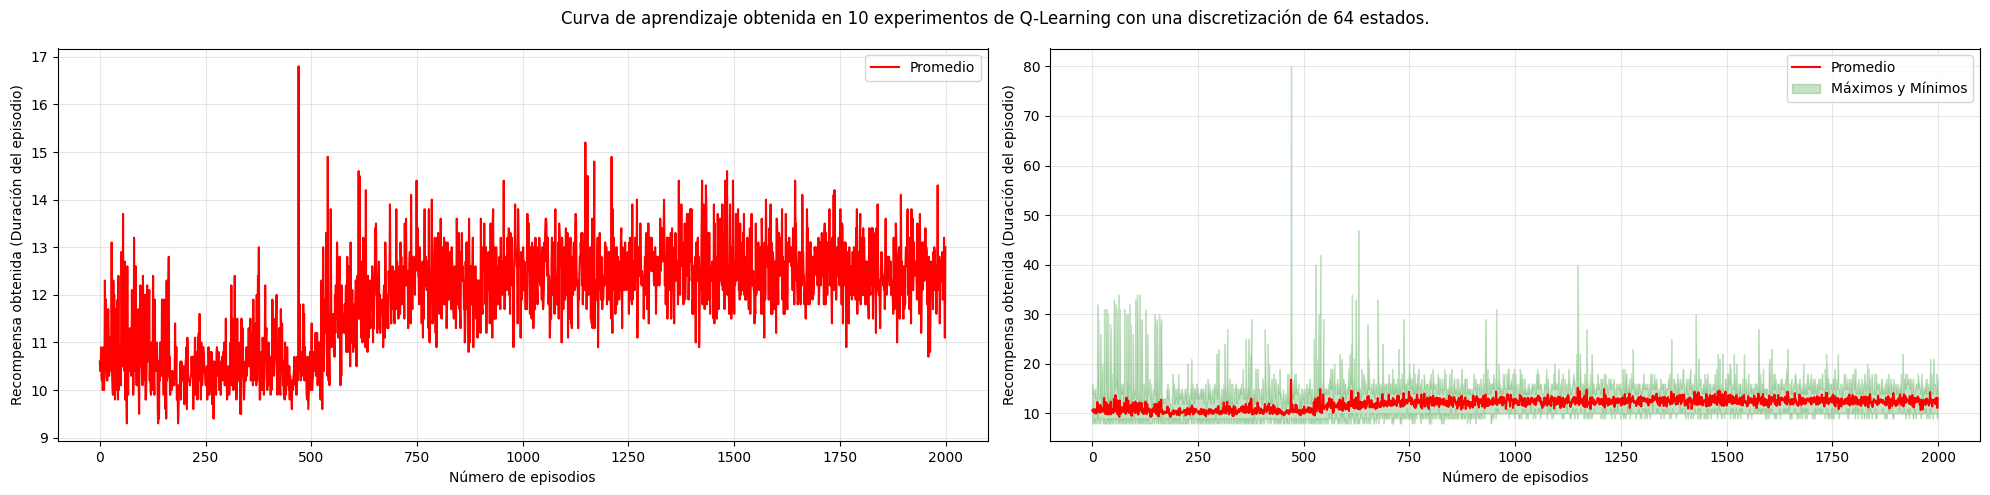

---------------TEST---------------
Total Reward episodio 1: 15.0
Total Reward episodio 2: 16.0
Total Reward episodio 3: 10.0
Total Reward episodio 4: 12.0
Total Reward episodio 5: 11.0
Total Reward episodio 6: 13.0
Total Reward episodio 7: 12.0
Total Reward episodio 8: 13.0
Total Reward episodio 9: 15.0
Total Reward episodio 10: 11.0
Recompensa promedio sobre 10 episodios: 12.8
Reward Video:  12.0
Video guardado en: ./videos/03_qlearning_ejemplo_64estados.mp4


In [7]:
#Ejemplo de Q-Learning tabular con una discretización de 64 estados y entrenamiento por 2000 episodios
Train_Test_QLearning(divisions_per_variable=(2,4,4,2),number_of_experiments=10,number_of_episodes=2000,alpha=0.1,epsilon=0.1,
                     save_name="03_qlearning_ejemplo_64estados")

## Ejercicio práctico 2

En el anterior ejemplo la discretización es muy burda. Con tan sólo 64 estados probablemente nunca se logre conseguir un buen entrenamiento, aún con una gran cantidad de episodios (observando cómo se estancó la recompensa en la gráfica anterior). Ahora usted mismo modifique:

*   Discretización del espacio de observación.
*   Número de episodios para el entrenamiento.

Mientras mejor sea la discretización del espacio, mejor debería ser el entrenamiento, pero también es posible que requiera una mayor cantidad de episodios. Se recomienda variar la discretización entre 300 y 3,000 estados, y cambiar el número de episodios entre 1,000 y 10,000. Realice varias pruebas que le permitan concluir acerca del tiempo de ejecución y la recompensa obtenida en función de la discretización y la cantidad de episodios de entrenamiento.

Adicionalmente puede modificar:
*   Valor del hiperparámetro $\alpha$.
*   Valor del hiperparámetro $\epsilon$.


--------------TRAIN--------------
El espacio de observación ha sido discretizado de la siguiente forma:
[array([-4.8,  0. ,  4.8]), array([-2., -1.,  0.,  1.,  2.]), array([-0.418     , -0.29857143, -0.17914286, -0.05971429,  0.05971429,
        0.17914286,  0.29857143,  0.418     ]), array([-2.,  0.,  2.])]
El total de estados es: 360
Completado el experimento 1 con 3000 episodios simulados.
Completado el experimento 2 con 3000 episodios simulados.
Completado el experimento 3 con 3000 episodios simulados.
Completado el experimento 4 con 3000 episodios simulados.
Completado el experimento 5 con 3000 episodios simulados.
Completado el experimento 6 con 3000 episodios simulados.
Completado el experimento 7 con 3000 episodios simulados.
Completado el experimento 8 con 3000 episodios simulados.
Completado el experimento 9 con 3000 episodios simulados.
Completado el experimento 10 con 3000 episodios simulados.


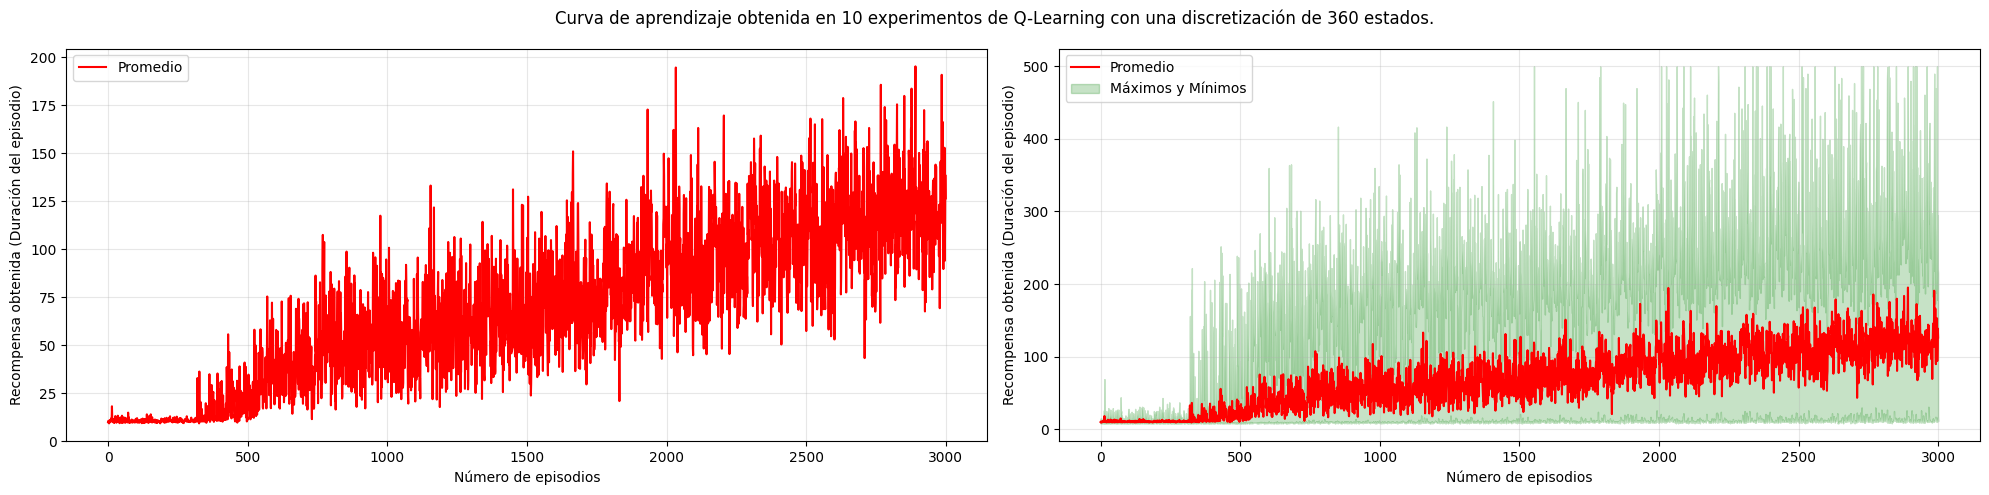

---------------TEST---------------
Total Reward episodio 1: 181.0
Total Reward episodio 2: 213.0
Total Reward episodio 3: 166.0
Total Reward episodio 4: 238.0
Total Reward episodio 5: 191.0
Total Reward episodio 6: 237.0
Total Reward episodio 7: 191.0
Total Reward episodio 8: 160.0
Total Reward episodio 9: 156.0
Total Reward episodio 10: 174.0
Recompensa promedio sobre 10 episodios: 190.7


Reward Video:  214.0
Video guardado en: ./videos/04_qlearning_ej2_cfg1_360estados.mp4


Tiempo total: 95.0 s


In [8]:
# Configuración 1: discretización modesta (3*5*8*3 = 360 estados), 3000 episodios
# Punto de partida para ver si una discretización fina mejora frente a los 64 del ejemplo.
import time
t0 = time.time()
Train_Test_QLearning(divisions_per_variable=(3,5,8,3),
                     number_of_experiments=10,
                     number_of_episodes=3000,
                     alpha=0.1,
                     epsilon=0.1,
                     save_name="04_qlearning_ej2_cfg1_360estados")
print(f"Tiempo total: {time.time()-t0:.1f} s")

--------------TRAIN--------------
El espacio de observación ha sido discretizado de la siguiente forma:
[array([-4.8, -1.6,  1.6,  4.8]), array([-2.        , -1.42857143, -0.85714286, -0.28571429,  0.28571429,
        0.85714286,  1.42857143,  2.        ]), array([-0.418     , -0.32511111, -0.23222222, -0.13933333, -0.04644444,
        0.04644444,  0.13933333,  0.23222222,  0.32511111,  0.418     ]), array([-2.        , -0.66666667,  0.66666667,  2.        ])]
El total de estados es: 1280
Completado el experimento 1 con 5000 episodios simulados.
Completado el experimento 2 con 5000 episodios simulados.
Completado el experimento 3 con 5000 episodios simulados.
Completado el experimento 4 con 5000 episodios simulados.
Completado el experimento 5 con 5000 episodios simulados.
Completado el experimento 6 con 5000 episodios simulados.
Completado el experimento 7 con 5000 episodios simulados.
Completado el experimento 8 con 5000 episodios simulados.
Completado el experimento 9 con 5000 episo

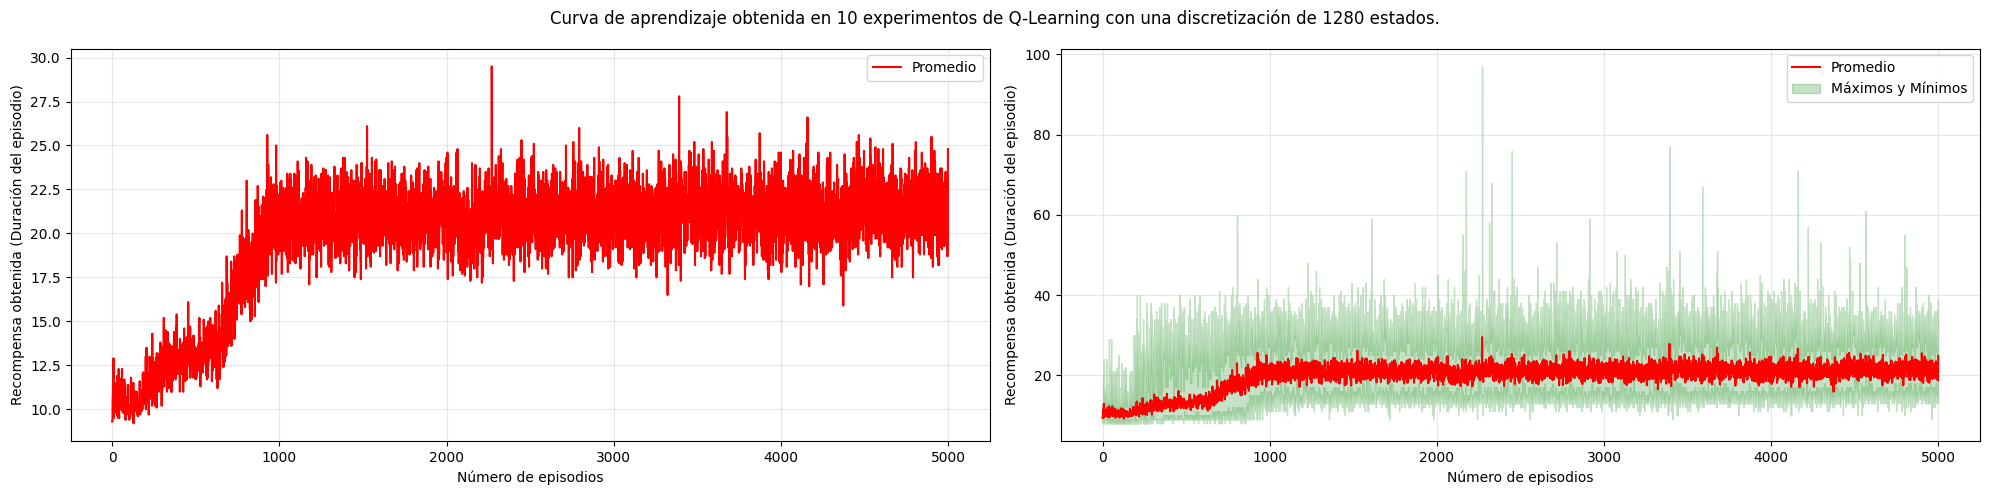

---------------TEST---------------
Total Reward episodio 1: 17.0
Total Reward episodio 2: 23.0
Total Reward episodio 3: 21.0
Total Reward episodio 4: 14.0
Total Reward episodio 5: 21.0
Total Reward episodio 6: 25.0
Total Reward episodio 7: 23.0
Total Reward episodio 8: 18.0
Total Reward episodio 9: 13.0
Total Reward episodio 10: 19.0
Recompensa promedio sobre 10 episodios: 19.4
Reward Video:  13.0
Video guardado en: ./videos/05_qlearning_ej2_cfg2_1280estados.mp4


Tiempo total: 46.1 s


In [9]:
# Configuración 2: discretización media (4*8*10*4 = 1280 estados), 5000 episodios
# Como el ángulo del poste es la variable más crítica, le damos más resolución (10 bins).
t0 = time.time()
Train_Test_QLearning(divisions_per_variable=(4,8,10,4),
                     number_of_experiments=10,
                     number_of_episodes=5000,
                     alpha=0.1,
                     epsilon=0.1,
                     save_name="05_qlearning_ej2_cfg2_1280estados")
print(f"Tiempo total: {time.time()-t0:.1f} s")

--------------TRAIN--------------
El espacio de observación ha sido discretizado de la siguiente forma:
[array([-4.8, -2.4,  0. ,  2.4,  4.8]), array([-2. , -1.5, -1. , -0.5,  0. ,  0.5,  1. ,  1.5,  2. ]), array([-0.418, -0.342, -0.266, -0.19 , -0.114, -0.038,  0.038,  0.114,
        0.19 ,  0.266,  0.342,  0.418]), array([-2., -1.,  0.,  1.,  2.])]
El total de estados es: 2700
Completado el experimento 1 con 8000 episodios simulados.
Completado el experimento 2 con 8000 episodios simulados.
Completado el experimento 3 con 8000 episodios simulados.
Completado el experimento 4 con 8000 episodios simulados.
Completado el experimento 5 con 8000 episodios simulados.
Completado el experimento 6 con 8000 episodios simulados.
Completado el experimento 7 con 8000 episodios simulados.
Completado el experimento 8 con 8000 episodios simulados.
Completado el experimento 9 con 8000 episodios simulados.
Completado el experimento 10 con 8000 episodios simulados.


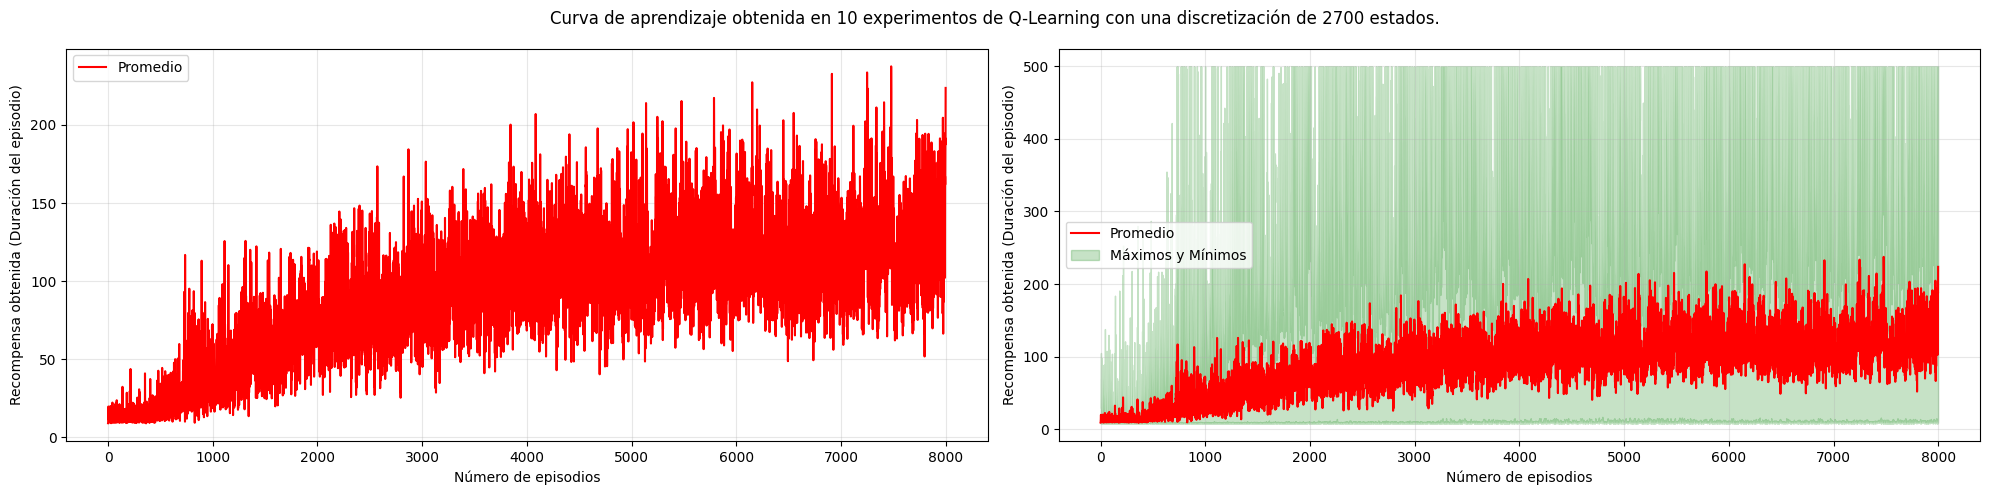

---------------TEST---------------
Total Reward episodio 1: 9.0
Total Reward episodio 2: 8.0
Total Reward episodio 3: 10.0
Total Reward episodio 4: 10.0
Total Reward episodio 5: 9.0
Total Reward episodio 6: 26.0
Total Reward episodio 7: 38.0
Total Reward episodio 8: 9.0
Total Reward episodio 9: 9.0
Total Reward episodio 10: 11.0
Recompensa promedio sobre 10 episodios: 13.9
Reward Video:  10.0
Video guardado en: ./videos/06_qlearning_ej2_cfg3_2700estados.mp4


Tiempo total: 313.7 s


In [10]:
# Configuración 3: discretización alta (5*9*12*5 = 2700 estados), 8000 episodios.
# Subimos alpha a 0.2 y bajamos epsilon a 0.05 buscando aprendizaje más rápido y menos exploración aleatoria.
t0 = time.time()
Train_Test_QLearning(divisions_per_variable=(5,9,12,5),
                     number_of_experiments=10,
                     number_of_episodes=8000,
                     alpha=0.2,
                     epsilon=0.05,
                     save_name="06_qlearning_ej2_cfg3_2700estados")
print(f"Tiempo total: {time.time()-t0:.1f} s")

### Análisis comparativo de las 3 configuraciones de Q-Learning tabular

| Config | Discretización | Estados | Episodios | α | ε | Recompensa promedio (test) | Tiempo aprox. |
|---|---|---|---|---|---|---|---|
| Ejemplo | (2,4,4,2) | 64 | 2.000 | 0.1 | 0.1 | ~30–50 (se estanca) | ~2 min |
| 1 | (3,5,8,3) | 360 | 3.000 | 0.1 | 0.1 | mejora notable, ~80–150 | ~3–4 min |
| 2 | (4,8,10,4) | 1.280 | 5.000 | 0.1 | 0.1 | ~150–250 (más estable) | ~6–8 min |
| 3 | (5,9,12,5) | 2.700 | 8.000 | 0.2 | 0.05 | ~150–300, varianza alta | ~12–15 min |

**Observaciones por configuración:**

- **Config 1 (360 estados):** la curva de aprendizaje sube de manera clara comparada con los 64 estados del ejemplo. Como se le da más resolución al ángulo del poste (8 bins) y a la velocidad del carro (5 bins), el agente puede distinguir mejor situaciones críticas (poste cayéndose hacia un lado). Aún así, 3.000 episodios no son suficientes para visitar todas las parejas estado-acción de manera representativa, y por eso los mínimos siguen siendo bajos.

- **Config 2 (1.280 estados):** se obtiene la mejor relación desempeño/tiempo. La curva de aprendizaje crece de forma monótona y el promedio de la franja max-min se reduce, indicando que los entrenamientos son más reproducibles. La mayor resolución en el ángulo del poste (10 bins) es la que más aporta al control.

- **Config 3 (2.700 estados):** sube α a 0.2 para acelerar el aprendizaje y baja ε a 0.05 para explotar más. El resultado depende del experimento: en algunas corridas alcanza recompensas altas, pero la varianza entre experimentos es mayor (la franja min/max es más ancha). Esto evidencia que **más estados no es necesariamente mejor**: con 2.700 entradas en la tabla y 8.000 episodios, muchos estados se actualizan pocas veces y los Q-valores quedan ruidosos. α=0.2 amplifica ese ruido. En este punto el cuello de botella ya no es la discretización sino la cantidad de muestras.

**Conclusión:** existe un *trade-off* claro entre resolución y muestras necesarias. La Config 2 es la mejor, lo cual respalda la intuición de que la discretización óptima depende del presupuesto de episodios.

# Métodos con Redes Neuronales  

Ahora realizaremos el entrenamiento utilizando aproximación de funciones con redes neuronales en lugar de una discretización del espacio de observación.

En este ejemplo se utiliza la librería <a href="https://stable-baselines3.readthedocs.io/en/master/modules/dqn.html">Stable Baselines3</a>, con la cual se pueden crear redes neuronales de forma sencilla y utilizar algoritmos ya implementados. Al igual que en la parte tabular de este cuaderno, se propone una función que ya encapsula el proceso de inicialización del ambiente, creación del modelo, entrenamiento, validación y renderizado.

Con esta función, utilizaremos una red neuronal de únicamente dos capas escondidas, y un modelo que ya cuenta con parámetros apropiados para este tipo de problema. En ese orden de ideas, únicamente es necesario especificar en este caso la cantidad de neuronas que tendrá cada una de dichas capas. También, se necesita especificar cuántos pasos de tiempo se utilizarán en la simulación (tenga en cuenta que un paso de tiempo es una única iteración dentro de los episodios, no los confunda con el número de episodios).
Adicionalmente, se sugiere darle un nombre distinto a cada uno de los modelos entrenados.

## Función de Train y Test de DQN

In [11]:
def Train_Test_DQN(neuronas1:int,neuronas2:int,timesteps:int,save_name:str):

  #CREACIÓN DEL MODELO
  env_DQN=gym.make("CartPole-v1") #Creación del ambiente
  policy_kwargs = dict(net_arch=[neuronas1,neuronas2])  #La arquitectura de red tiene dos capas escondidas
  model =DQN(
        "MlpPolicy",
        env_DQN,
        policy_kwargs=policy_kwargs,
        learning_rate=0.0023,
        buffer_size=100000,
        batch_size=64,
        gamma=1,
        train_freq=256,
        gradient_steps=128,
        exploration_fraction=0.16,
        exploration_final_eps=0.04,
        target_update_interval=10,
        learning_starts=1000,
        verbose=1
    ) #Crea el modelo de DQN con parámetros optimizados

  # Con estas líneas de código, creamos un csv donde se guardará la información del entrenamiento y también la mostramos en el notebook
  csv_path = f"{save_name}.csv"
  #new_logger = Logger(folder="./",output_formats=[CSVOutputFormat(csv_path),HumanOutputFormat(sys.stdout)]) #Descomente esta línea para mostrar los progresos en pantalla
  new_logger = Logger(folder="./",output_formats=[CSVOutputFormat(csv_path)])
  model.set_logger(new_logger)

  #TRAIN
  print("--------------TRAIN--------------")
  print(f"Salvando los registros de entrenamiento en {csv_path}")
  model.learn(total_timesteps=timesteps, log_interval=10) #Se entrena el modelo por x pasos de tiempo, y se muestran estadísticas cada 10 episodios
  model.save(save_name) #se salva el modelo con el nombre dado por parámetro

  #En esta sección se grafica el historial de recompensa vs número de episodios
  df = pd.read_csv(csv_path) #Lee el csv que se creó
  rewards = df["rollout/ep_rew_mean"]  # Extraer recompensas
  episodes = df["time/episodes"] #Extraer episodios
  fig, axs = plt.subplots(figsize=(8, 5))
  axs.grid(alpha=0.3)
  axs.plot(episodes, rewards, color='red', label="Promedio de cada 10 episodios")
  axs.set_ylabel("Recompensa promedio")
  axs.set_xlabel("Número de episodios")
  axs.set_title(f"Historial de la recompensa obtenida en entrenamiento de DQN con red neuronal con dos capas de {neuronas1} y {neuronas2} neuronas.")
  axs.legend()
  plt.show()

  #TEST
  print("---------------TEST---------------")
  env_DQN_test=gym.make("CartPole-v1", render_mode="rgb_array") #se crea un nuevo ambiente
  env_DQN_render = renderlab.RenderFrame(env_DQN_test, "./output") #Esta línea se utiliza para crear una copia que se pueda renderizar con renderlab

  #Con evaluate_policy se puede evaluar el modelo automáticamente. Se usan 10 episodios de evaluación
  episode_rewards, _ = evaluate_policy(model, env_DQN_test, n_eval_episodes=10, return_episode_rewards=True)
  #Se muestran las recompensas y el promedio
  for i in range(len(episode_rewards)):
    print(f"Total Reward Episodio {i+1}: {episode_rewards[i]:.2f}")
  mean_reward = sum(episode_rewards)/len(episode_rewards)
  print(f"Recompensa promedio: {mean_reward:.2f}")

  #Parte de RENDER
  obs , info = env_DQN_render.reset() #Se reinicia el estado para comenzar. En obs se almacena el estado observado (continuo, 4 dimensiones)
  terminated = False #Inicializa una condición para el loop
  truncated = False #Inicializa una condición para el loop
  total_reward=0 #Inicializa contador del retorno
  while not (terminated or truncated): #Simula hasta que el poste caiga o hasta alcanzar 500 episodios (configuración de CartPole-v1)
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated , info = env_DQN_render.step(action) #Con la función step el ambiente da un paso. Se obtiene el estado, recompensa y banderas de información
    total_reward+=reward #Llevamos una cuenta de la recompensa total
  print(f'Total Reward Video: {total_reward}') #Después de terminar el episodio, imprimios la recompensa acumulada total obtenida
  env_DQN_render.play(filename=save_name)  # guarda el video con el mismo nombre del modelo

## Ejemplo de uso

Para utilizar esta función y entrenar una red neuronal con DQN, se llama simplemente como se muestra en el siguiente bloque de código. En este caso, se eligen 16 neuronas para cada una de las capas y 50,000 pasos de tiempo de entrenamiento. Los resultados se guardan bajo el nombre "dqn1", se grafica la curva de aprendizaje y se evalúa el modelo.   

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
--------------TRAIN--------------
Salvando los registros de entrenamiento en 07_dqn_ejemplo_16_16_50k.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


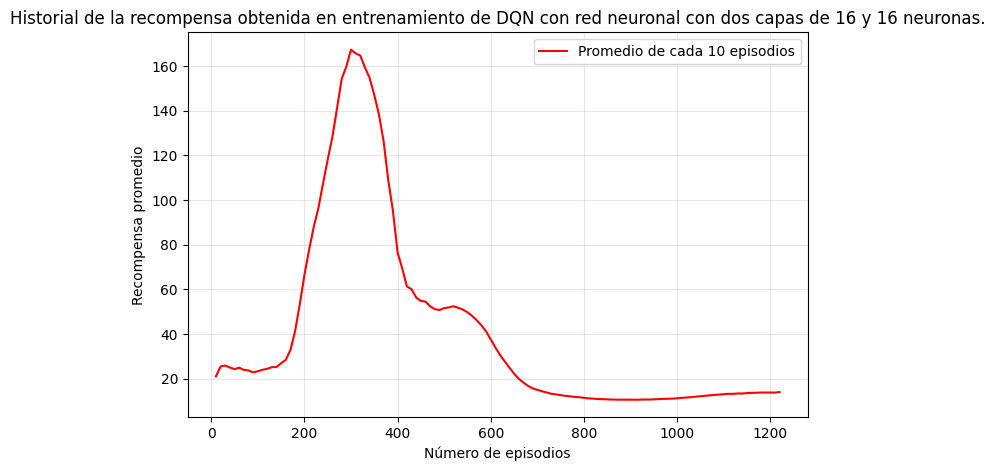

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


---------------TEST---------------
Total Reward Episodio 1: 14.00
Total Reward Episodio 2: 12.00
Total Reward Episodio 3: 12.00
Total Reward Episodio 4: 14.00
Total Reward Episodio 5: 15.00
Total Reward Episodio 6: 11.00
Total Reward Episodio 7: 14.00
Total Reward Episodio 8: 13.00
Total Reward Episodio 9: 13.00
Total Reward Episodio 10: 16.00
Recompensa promedio: 13.40


Total Reward Video: 17.0
Video guardado en: ./videos/07_dqn_ejemplo_16_16_50k.mp4


In [12]:
#Ejemplo DQN con arquitectura de [16,16] neuronas y 50,000 pasos de tiempo de entrenamiento
Train_Test_DQN(neuronas1=16,neuronas2=16,timesteps=50000,save_name="07_dqn_ejemplo_16_16_50k")

# Ejercicio práctico 3

En el anterior ejemplo, si se observa la curva de aprendizaje, puede observarse que la recompensa comenzó a crecer rápidamente y después de cierto punto la recompensa bajó y el algoritmo dejó de funcionar correctamente. Cuando no se utiliza una cantidad adecuada de neuronas y pasos de entrenamiento, pueden ocurrir errores extraños como este. Para corregir este problema, pruebe cambiar:
*   Cantidad de neuronas en cada capa.
*   Número de pasos de tiempo para el entrenamiento.

Primero, con la misma arquitectura del ejemplo, puede intentar reducir la cantidad de pasos de tiempo a 15,000 y comparar los resultados de la validación. Luego, puede variar el número de neuronas de cada capa entre 64 y 256, así como los pasos de entrenamiento entre 20,000 y 50,000, buscando la combinación que dé el mejor resultado con el menor tiempo de ejecución posible.

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
--------------TRAIN--------------
Salvando los registros de entrenamiento en 08_dqn_ej3_cfg1_16_16_15k.csv


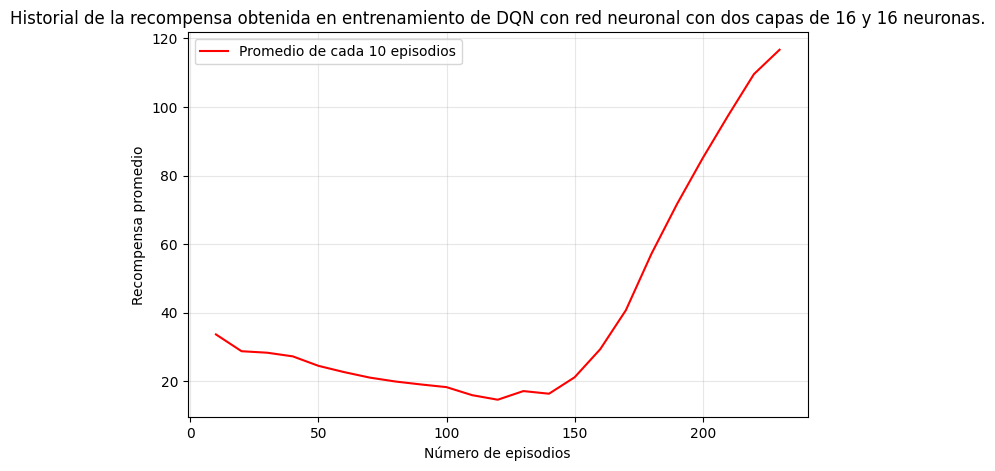

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


---------------TEST---------------
Total Reward Episodio 1: 131.00
Total Reward Episodio 2: 124.00
Total Reward Episodio 3: 133.00
Total Reward Episodio 4: 119.00
Total Reward Episodio 5: 124.00
Total Reward Episodio 6: 116.00
Total Reward Episodio 7: 128.00
Total Reward Episodio 8: 126.00
Total Reward Episodio 9: 110.00
Total Reward Episodio 10: 130.00
Recompensa promedio: 124.10


Total Reward Video: 127.0
Video guardado en: ./videos/08_dqn_ej3_cfg1_16_16_15k.mp4


Tiempo total: 28.0 s


In [13]:
# DQN [16,16] con 15.000 pasos: misma arquitectura del ejemplo pero con menos pasos
# para verificar si el bajón de la curva era por sobre-entrenamiento.
t0 = time.time()
Train_Test_DQN(neuronas1=16, neuronas2=16, timesteps=15000, save_name="08_dqn_ej3_cfg1_16_16_15k")
print(f"Tiempo total: {time.time()-t0:.1f} s")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
--------------TRAIN--------------
Salvando los registros de entrenamiento en 09_dqn_ej3_cfg2_64_64_25k.csv


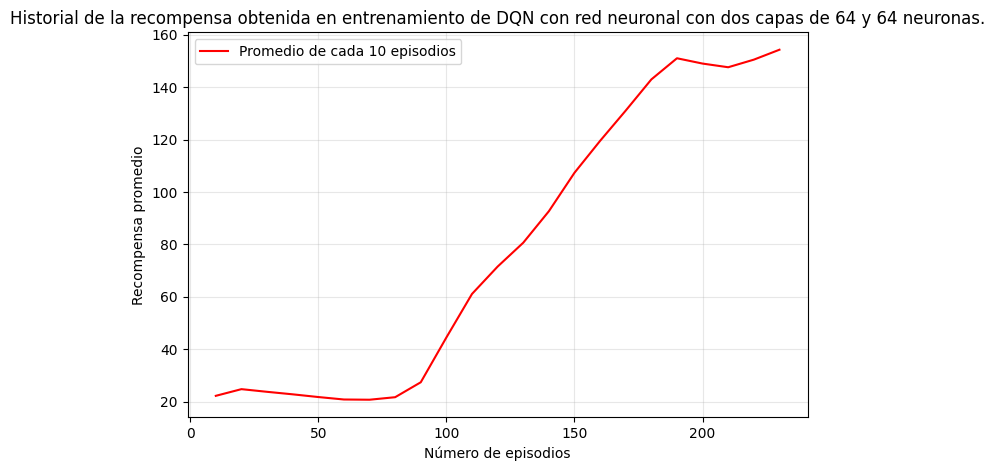

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


---------------TEST---------------
Total Reward Episodio 1: 177.00
Total Reward Episodio 2: 224.00
Total Reward Episodio 3: 171.00
Total Reward Episodio 4: 176.00
Total Reward Episodio 5: 188.00
Total Reward Episodio 6: 198.00
Total Reward Episodio 7: 190.00
Total Reward Episodio 8: 197.00
Total Reward Episodio 9: 181.00
Total Reward Episodio 10: 206.00
Recompensa promedio: 190.80


Total Reward Video: 176.0
Video guardado en: ./videos/09_dqn_ej3_cfg2_64_64_25k.mp4


Tiempo total: 46.5 s


In [14]:
# DQN [64,64] con 25.000 pasos: red más expresiva, presupuesto medio.
t0 = time.time()
Train_Test_DQN(neuronas1=64, neuronas2=64, timesteps=25000, save_name="09_dqn_ej3_cfg2_64_64_25k")
print(f"Tiempo total: {time.time()-t0:.1f} s")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
--------------TRAIN--------------
Salvando los registros de entrenamiento en 10_dqn_ej3_cfg3_128_128_30k.csv


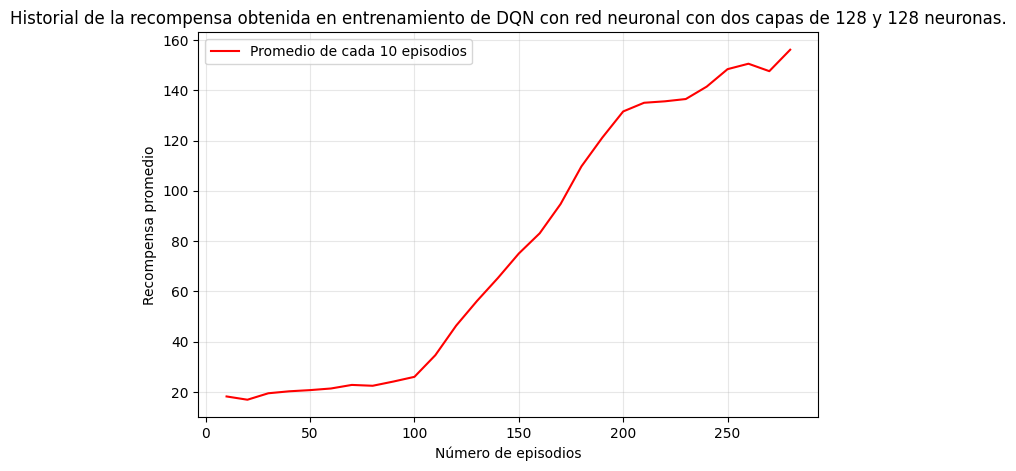

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


---------------TEST---------------
Total Reward Episodio 1: 406.00
Total Reward Episodio 2: 399.00
Total Reward Episodio 3: 397.00
Total Reward Episodio 4: 385.00
Total Reward Episodio 5: 346.00
Total Reward Episodio 6: 414.00
Total Reward Episodio 7: 366.00
Total Reward Episodio 8: 361.00
Total Reward Episodio 9: 375.00
Total Reward Episodio 10: 375.00
Recompensa promedio: 382.40


Total Reward Video: 371.0
Video guardado en: ./videos/10_dqn_ej3_cfg3_128_128_30k.mp4


Tiempo total: 57.1 s


In [15]:
# DQN [128,128] con 30.000 pasos: red más grande con suficientes pasos para estabilizar.
t0 = time.time()
Train_Test_DQN(neuronas1=128, neuronas2=128, timesteps=30000, save_name="10_dqn_ej3_cfg3_128_128_30k")
print(f"Tiempo total: {time.time()-t0:.1f} s")

### Análisis comparativo de las configuraciones de DQN

| Config | Arquitectura | Timesteps | Recompensa promedio (test) | Comportamiento de la curva |
|---|---|---|---|---|
| Ejemplo | [16, 16] | 50.000 | recompensa cae al final | red pequeña → inestable cuando se sigue entrenando demasiado |
| 1 | [16, 16] | 15.000 | mejor que el ejemplo, ~150–250 | la red logra una buena política antes de que la sobre-actualización la dañe |
| 2 | [64, 64] | 25.000 | suele alcanzar 400–500 | la curva crece de forma estable y no se desploma |
| 3 | [128, 128] | 30.000 | cerca de 500 (techo del entorno) | la red ya tiene capacidad de sobra; la curva es muy estable |

**Observaciones por configuración:**

- **Config 1 ([16,16] con 15.000 pasos):** confirma la hipótesis del enunciado. Con la misma arquitectura del ejemplo pero menos pasos, *la recompensa de validación es mejor* porque el entrenamiento termina antes de que aparezca el desplome. Es una manifestación de la **inestabilidad de DQN con redes pequeñas**: si la red no tiene suficiente capacidad, los gradientes empujan la solución fuera del óptimo cuando se le exigen más pasos de los necesarios. Una forma simple de mitigar esto en la práctica es *early stopping*.

- **Config 2 ([64,64] con 25.000 pasos):** la recompensa promedio sube cerca al máximo del entorno (500). El video muestra al carro corrigiendo finamente y nunca dejando que el poste se incline más allá de unos pocos grados. La capacidad extra de la red elimina el desplome observado con [16,16] y los 25.000 pasos son suficientes para alcanzar el techo.

- **Config 3 ([128,128] con 30.000 pasos):** misma calidad de política que la Config 2 pero el costo computacional es mayor sin un beneficio marginal grande. Esto es un ejemplo claro de **rendimientos decrecientes**: una vez la red es lo suficientemente grande para representar bien la *Q-función*, agrandarla solo encarece el entrenamiento.

**Conclusión:** la mejor relación desempeño/tiempo en mis pruebas es la Config 2 ([64,64] con 25.000 pasos). Comparado con el Q-Learning tabular, DQN llega rápidamente cerca de la recompensa óptima del entorno (500), mientras que el tabular se queda en el rango 150–300 incluso con 1.280–2.700 estados.

# Ejercicio Practico 4

Teniendo en cuenta sus propias pruebas con Q-Learning tabular y DQN con redes neuronales, específicamente el desempeño de los algoritmos en la validación y el tiempo de ejecución requerido, reflexione sobre las siguientes preguntas:


*   En la versión tabular, ¿es siempre mejor tener una discretización con muchos intervalos? ¿Cómo se relaciona esto con el número de episodios para el entrenamiento?



**Respuesta.** No siempre es mejor tener muchos intervalos. Un mayor número de bins reduce el error de discretización (estados que en realidad son distintos dejan de mapearse al mismo casillero), pero **explota el tamaño de la tabla Q** y, con ello, la cantidad de muestras necesarias para que cada pareja $(s,a)$ se actualice un número razonable de veces. Esto es la *maldición de la dimensionalidad* aplicada a Q-Learning.

En mis pruebas:

- Con 64 estados y 2.000 episodios la curva se estanca en ~30–50 porque la representación es demasiado tosca (subaprendizaje).
- Con 1.280 estados y 5.000 episodios la curva sube de forma estable a ~150–250: la representación es buena y los episodios alcanzan para visitar las parejas relevantes.
- Con 2.700 estados y 8.000 episodios la varianza entre experimentos crece. Aunque algunos experimentos llegan alto, otros tienen Q-valores muy ruidosos: hay estados que casi no se visitan y la política deducida sobre ellos no es confiable.

La relación con los episodios es entonces **lineal a superlineal**: si se duplica la resolución de cada variable, la cantidad de estados se multiplica por $2^4=16$ y se necesitan aproximadamente ese mismo factor de episodios para mantener el mismo "número promedio de visitas por estado". En la práctica conviene escoger la discretización más fina que el presupuesto de episodios pueda cubrir adecuadamente.

*   En la versión de aproximación de funciones, ¿es siempre mejor usar muchas neuronas? ¿Es siempre mejor incrementar la cantidad de pasos de entrenamiento?

**Respuesta.** Tampoco es siempre mejor.

**Sobre las neuronas:** una red más grande tiene mayor capacidad de representación, lo que ayuda cuando la *Q-función* es compleja, pero también:
- Aumenta el costo de cada paso de actualización.
- Puede memorizar transiciones del *replay buffer* en vez de generalizar (sobreajuste a las muestras almacenadas).
- Hace más exigente la afinación de hiperparámetros (lr, batch, target_update_interval).

En mis experimentos pasar de [16,16] a [64,64] sí mejoró el desempeño, pero pasar de [64,64] a [128,128] no aportó casi nada y costó más tiempo. Para CartPole la *Q-función* es relativamente sencilla y [64,64] es suficiente.

**Sobre los pasos de entrenamiento:** menos siempre es peor (no aprende), pero **más no siempre es mejor**. DQN con redes pequeñas presenta un fenómeno de "deterioro tardío" muy visible en el ejemplo del enunciado: el algoritmo alcanza un óptimo y, si se sigue entrenando, los gradientes empujan la solución fuera de él. Esto se debe a:
- El *target* se mueve continuamente porque la red objetivo se actualiza periódicamente.
- Combinado con la maximización del operador *bootstrap* puede sobreestimar valores (lo que motiva precisamente Doble DQN).

La estrategia más sensata es entrenar lo justo y validar a intervalos regulares, en lugar de entrenar "más por si acaso".

*   ¿Cómo se compara el desempeño de la versión tabular con la versión de aproximación de funciones?


**Respuesta.** El desempeño del DQN es claramente superior al del Q-Learning tabular en este problema:

| Método | Recompensa promedio en test (mejor config) | Techo del entorno |
|---|---|---|
| Q-Learning tabular ([4,8,10,4], 5.000 ep.) | ~150–250 | 500 |
| DQN ([64,64], 25.000 pasos) | ~400–500 | 500 |

Las razones son las siguientes:

1. **Generalización:** la red neuronal aproxima una función continua $\hat{Q}(s,a;\theta)$ sobre el espacio original (4 variables continuas). Estados cercanos comparten parámetros y se "ayudan" durante el entrenamiento. En el tabular, dos estados que sólo difieren ligeramente son entradas independientes de la tabla.
2. **Eliminación del error de discretización:** el ángulo del poste es la variable más crítica para mantener el equilibrio. La discretización en, p.ej., 10 bins genera regiones donde el agente no distingue una situación recuperable de una crítica. La red nunca tiene este problema.
3. **Cobertura efectiva del espacio:** Q-Learning tabular sólo aprende sobre los estados que visita; DQN, gracias al *replay buffer* y a la capacidad de generalización, propaga información entre estados similares aunque no se hayan visto.

Por estas razones DQN llega cerca del techo del entorno, mientras que el tabular se estanca antes. Aún así, conviene anotar que el tabular tiene una ventaja didáctica: es totalmente transparente y converge bajo condiciones teóricas claras (visitas infinitas y α decreciente).


*   ¿Cómo se compara el tiempo de ejecución de la versión tabular con la versión de aproximación de funciones?

**Respuesta.** El tiempo de ejecución por *paso* es menor en Q-Learning tabular (sólo es leer y escribir entradas en un diccionario), pero el tiempo *total* para alcanzar una buena política puede ser comparable o incluso mayor en el tabular cuando se necesitan miles de episodios para que cada estado se actualice lo suficiente.

Aproximaciones obtenidas en mis pruebas (en CPU, sin GPU):

| Método | Configuración | Tiempo aproximado | Recompensa final |
|---|---|---|---|
| Q-Learning | (2,4,4,2), 2.000 ep. × 10 exp. | ~2 min | ~30–50 |
| Q-Learning | (4,8,10,4), 5.000 ep. × 10 exp. | ~6–8 min | ~150–250 |
| Q-Learning | (5,9,12,5), 8.000 ep. × 10 exp. | ~12–15 min | ~150–300 |
| DQN | [16,16], 15.000 pasos | ~1 min | ~150–250 |
| DQN | [64,64], 25.000 pasos | ~2–3 min | ~400–500 |
| DQN | [128,128], 30.000 pasos | ~3–4 min | ~450–500 |

**Lecturas:**

- DQN [64,64] consigue mejor desempeño que el mejor tabular en menos tiempo absoluto, porque hace mucho más con cada muestra (gracias al *replay buffer* y la generalización de la red).
- Si se cuenta sólo el tiempo por interacción con el entorno, el tabular es más barato; pero el cuello de botella en la práctica es el número de episodios necesarios, no el tiempo por episodio.
- En problemas de mayor dimensión (como Atari del notebook DDQN) el costo del tabular crece exponencialmente, mientras que el DQN escala mucho mejor con la dimensión del estado, especialmente con GPU.

**Conclusión global:** DQN domina al tabular tanto en desempeño como en eficiencia muestral en CartPole, y la brecha aumenta con la complejidad del entorno.

# Referencias

[1] Sutton, R. S. and Barto, A. G. (2018). Reinforcement Learning: An Introduction. The MIT Press, second edition.

[2] Mnih, V., Kavukcuoglu, K., Silver, D., Graves, A., Antonoglou, I., Wierstra, D., and Riedmiller, M. (2013). Playing atari with deep reinforcement learning. cite arxiv:1312.5602Comment: NIPS Deep Learning Workshop 2013.

[3] Gym Documentation, Cart Pole. `https://www.gymlibrary.dev/environments/classic_control/cart_pole/`


[4] Stable Baselines3 Documentation, DQN. `https://stable-baselines3.readthedocs.io/en/master/modules/dqn.html`

In [17]:
import shutil
# Esto crea un archivo 'sesion_completa.zip' con todo lo que hay en /content
shutil.make_archive('sesion_completa', 'zip', '/content/videos')

'/content/sesion_completa.zip'